# Little's Law: the free lunch of queueing

`L = λ · W`. The average number of items in *any* stable system equals the arrival rate times the
average time each item spends inside. That's it — and it holds for **any** arrival process, **any**
service distribution, **any** scheduling discipline, and any box you draw around a subsystem. No
Poisson assumption, no independence, nothing.

Why an engineer should care: it turns quantities that are **hard to measure** into ones that are
**easy to measure**. Can't instrument per-request latency `W`? Measure throughput `λ` and average
concurrency `L` (both trivial to log) and read off `W = L/λ`. Or the reverse. It's an exact
accounting identity, not an approximation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.random.distributions import GammaDistribution
from most_queue.sim.base import QsSim
from most_queue.sim.single_server_disciplines import ProcessorSharingSim, FBSim

plt.rcParams.update({"figure.figsize": (7, 6), "axes.grid": True, "font.size": 11})

def measure_L_and_W(sim, njobs=200_000):
    res = sim.run(njobs)
    if hasattr(sim, "get_p"):
        p = np.asarray(sim.get_p())          # time-average distribution of #-in-system
    else:
        pt = np.asarray(sim.p_time, dtype=float); p = pt / pt.sum()
    L = float(sum(n * p[n] for n in range(len(p))))
    W = res.v[0]                             # mean time in system, measured independently
    return L, W

def gamma(mean, cv):
    return GammaDistribution.get_params_by_mean_and_cv(mean, cv)


## Verify it across loads, service distributions and disciplines

We simulate a variety of single-server systems and, for each, measure the average number in system
`L` and the average sojourn `W` **independently** (one from the state process, the other from
per-job timestamps). Little's Law predicts every point lands on the line `L = λW`.

Start simulation


Job served:    | 0/100 [00:00<?, ?it/s]2000/200000:   1%|          | 1/100 [00:00<00:02, 45.64it/s]4000/200000:   2%|▏         | 2/100 [00:00<00:02, 33.23it/s]6000/200000:   3%|▎         | 3/100 [00:00<00:02, 35.45it/s]6000/200000:   4%|▍         | 4/100 [00:00<00:02, 38.57it/s]8000/200000:   4%|▍         | 4/100 [00:00<00:02, 38.57it/s]10000/200000:   5%|▌         | 5/100 [00:00<00:02, 38.57it/s]12000/200000:   6%|▌         | 6/100 [00:00<00:02, 38.57it/s]14000/200000:   7%|▋         | 7/100 [00:00<00:02, 38.57it/s]16000/200000:   8%|▊         | 8/100 [00:00<00:02, 38.57it/s]18000/200000:   9%|▉         | 9/100 [00:00<00:02, 38.57it/s]18000/200000:  10%|█         | 10/100 [00:00<00:01, 47.16it/s]20000/200000:  10%|█         | 10/100 [00:00<00:01, 47.16it/s]22000/200000:  11%|█         | 11/100 [00:00<00:01, 47.16it/s]24000/200000:  12%|█▏        | 12/100 [00:00<00:01, 47.16it/s]26000/200000:  13%|█▎        | 13/100 [00:00<00:01, 47.16it/s]28000/200000:  14%|█▍        | 14/100 [00:00<0

Simulation is finished

Start simulation


Job served:    | 0/100 [00:00<?, ?it/s]2000/200000:   1%|          | 1/100 [00:00<00:01, 58.89it/s]4000/200000:   2%|▏         | 2/100 [00:00<00:01, 56.42it/s]6000/200000:   3%|▎         | 3/100 [00:00<00:01, 55.94it/s]8000/200000:   4%|▍         | 4/100 [00:00<00:01, 55.39it/s]10000/200000:   5%|▌         | 5/100 [00:00<00:01, 55.29it/s]10000/200000:   6%|▌         | 6/100 [00:00<00:01, 54.84it/s]12000/200000:   6%|▌         | 6/100 [00:00<00:01, 54.84it/s]14000/200000:   7%|▋         | 7/100 [00:00<00:01, 54.84it/s]16000/200000:   8%|▊         | 8/100 [00:00<00:01, 54.84it/s]18000/200000:   9%|▉         | 9/100 [00:00<00:01, 54.84it/s]20000/200000:  10%|█         | 10/100 [00:00<00:01, 54.84it/s]22000/200000:  11%|█         | 11/100 [00:00<00:01, 54.84it/s]22000/200000:  12%|█▏        | 12/100 [00:00<00:01, 52.08it/s]24000/200000:  12%|█▏        | 12/100 [00:00<00:01, 52.08it/s]26000/200000:  13%|█▎        | 13/100 [00:00<00:01, 52.08it/s]28000/200000:  14%|█▍        | 14/100 [00:00<

Simulation is finished

Start simulation


...

Simulation is finished

Start simulation


Job served:    | 0/100 [00:00<?, ?it/s]2000/200000:   1%|          | 1/100 [00:00<00:02, 37.84it/s]4000/200000:   2%|▏         | 2/100 [00:00<00:02, 39.59it/s]6000/200000:   3%|▎         | 3/100 [00:00<00:02, 44.14it/s]8000/200000:   4%|▍         | 4/100 [00:00<00:02, 45.09it/s]8000/200000:   5%|▌         | 5/100 [00:00<00:02, 47.18it/s]10000/200000:   5%|▌         | 5/100 [00:00<00:02, 47.18it/s]12000/200000:   6%|▌         | 6/100 [00:00<00:01, 47.18it/s]14000/200000:   7%|▋         | 7/100 [00:00<00:01, 47.18it/s]16000/200000:   8%|▊         | 8/100 [00:00<00:01, 47.18it/s]18000/200000:   9%|▉         | 9/100 [00:00<00:01, 47.18it/s]20000/200000:  10%|█         | 10/100 [00:00<00:01, 47.18it/s]20000/200000:  11%|█         | 11/100 [00:00<00:01, 47.76it/s]22000/200000:  11%|█         | 11/100 [00:00<00:01, 47.76it/s]24000/200000:  12%|█▏        | 12/100 [00:00<00:01, 47.76it/s]26000/200000:  13%|█▎        | 13/100 [00:00<00:01, 47.76it/s]28000/200000:  14%|█▍        | 14/100 [00:00<0

Simulation is finished

Start simulation


Job served:    | 0/100 [00:00<?, ?it/s]2000/200000:   1%|          | 1/100 [00:00<00:02, 39.96it/s]4000/200000:   2%|▏         | 2/100 [00:00<00:02, 45.72it/s]6000/200000:   3%|▎         | 3/100 [00:00<00:02, 48.16it/s]8000/200000:   4%|▍         | 4/100 [00:00<00:01, 49.63it/s]10000/200000:   5%|▌         | 5/100 [00:00<00:01, 50.83it/s]10000/200000:   6%|▌         | 6/100 [00:00<00:01, 51.24it/s]12000/200000:   6%|▌         | 6/100 [00:00<00:01, 51.24it/s]14000/200000:   7%|▋         | 7/100 [00:00<00:01, 51.24it/s]16000/200000:   8%|▊         | 8/100 [00:00<00:01, 51.24it/s]18000/200000:   9%|▉         | 9/100 [00:00<00:01, 51.24it/s]20000/200000:  10%|█         | 10/100 [00:00<00:01, 51.24it/s]22000/200000:  11%|█         | 11/100 [00:00<00:01, 51.24it/s]22000/200000:  12%|█▏        | 12/100 [00:00<00:01, 50.78it/s]24000/200000:  12%|█▏        | 12/100 [00:00<00:01, 50.78it/s]26000/200000:  13%|█▎        | 13/100 [00:00<00:01, 50.78it/s]28000/200000:  14%|█▍        | 14/100 [00:00<

Simulation is finished



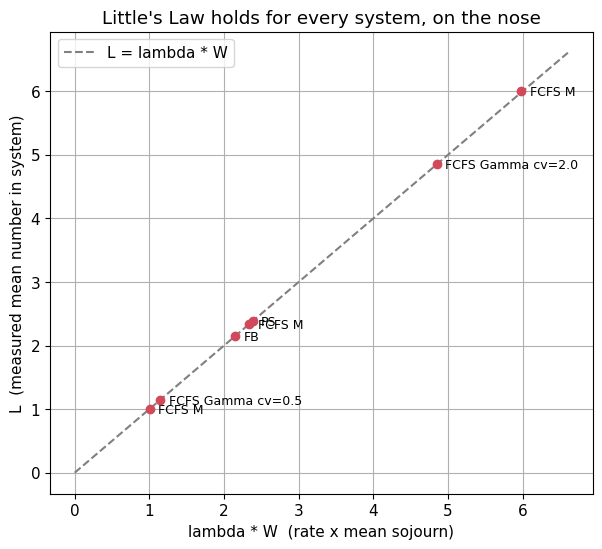

FCFS M            lambda*W =  1.003   L =  1.004   ratio = 1.0007
FCFS M            lambda*W =  2.339   L =  2.337   ratio = 0.9992
FCFS M            lambda*W =  5.982   L =  6.004   ratio = 1.0036
FCFS Gamma cv=0.5  lambda*W =  1.147   L =  1.143   ratio = 0.9966
FCFS Gamma cv=2.0  lambda*W =  4.848   L =  4.849   ratio = 1.0004
PS                lambda*W =  2.381   L =  2.389   ratio = 1.0032
FB                lambda*W =  2.147   L =  2.144   ratio = 0.9987


In [2]:
points = []   # (lambda*W, L, label)

# FCFS at different loads and service distributions (M, low-CV Gamma, high-CV Gamma)
fcfs_cfgs = [(0.5, "M", None), (0.7, "M", None), (0.85, "M", None),
             (0.6, "Gamma", 0.5), (0.7, "Gamma", 2.0)]
for lam, kind, cv in fcfs_cfgs:
    s = QsSim(1, verbose=False, seed=1)
    s.set_sources(lam, "M")
    s.set_servers(1.0 if kind == "M" else gamma(1.0, cv), kind)
    L, W = measure_L_and_W(s)
    points.append((lam * W, L, f"FCFS {kind}{'' if cv is None else f' cv={cv}'}"))

# same load, different disciplines (very different W and L, identity still holds)
for name, S in [("PS", ProcessorSharingSim), ("FB", FBSim)]:
    s = S(); s.set_sources(0.7, "M"); s.set_servers(gamma(1.0, 2.0), "Gamma")
    L, W = measure_L_and_W(s)
    points.append((0.7 * W, L, name))

xy = np.array([(a, b) for a, b, _ in points])
fig, ax = plt.subplots()
lim = xy.max() * 1.1
ax.plot([0, lim], [0, lim], "--", color="gray", label="L = lambda * W")
ax.scatter(xy[:, 0], xy[:, 1], color="#d1495b", zorder=5)
for a, b, lab in points:
    ax.annotate(lab, (a, b), textcoords="offset points", xytext=(6, -3), fontsize=9)
ax.set_xlabel("lambda * W  (rate x mean sojourn)")
ax.set_ylabel("L  (measured mean number in system)")
ax.set_title("Little's Law holds for every system, on the nose")
ax.legend()
plt.show()

for a, b, lab in points:
    print(f"{lab:16}  lambda*W = {a:6.3f}   L = {b:6.3f}   ratio = {b/a:.4f}")


**The insight.** Every point sits on `L = λW`, whether the discipline is FCFS, Processor Sharing
or Foreground-Background, and whatever the service distribution. PS and FB have *very different* `W`
(and hence `L`) than FCFS — but the identity linking their own `L` and `W` is exact.

## What it buys you in practice

- **Latency from concurrency.** Your service reports throughput (`λ`, req/s) and average in-flight
  requests (`L`, e.g. from a gauge). Then average latency is `W = L/λ` — no per-request tracing.
- **Sanity checks.** If measured `L`, `λ`, `W` don't satisfy `L = λW`, your measurement window,
  warm-up, or definitions are off.
- **Any boundary.** Apply it to the queue only (`L_q = λ W_q`), to one tier, or to the whole
  pipeline. It composes.

## Takeaways

- `L = λW` is an **exact identity** for any stable system — distribution-free, discipline-free.
- Use it to derive the metric you can't measure from the two you can.
- It is the single most useful one-line result in queueing.